# SnakeGuard AI — Snake Species Classification

## 1. Import & Config

In [ ]:
# # for Kaggle or Colab
# !pip install -q timm

In [ ]:
from pathlib import Path
import random

import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode

import timm
from tqdm.auto import tqdm

In [ ]:
DATA_DIR = Path("/kaggle/input/datasets/lthhnglam/vn-snakeclef2023-crop/VN-SnakeCLEF2023-CROP")
CKPT = Path("/kaggle/input/datasets/lthhnglam/convnextv2-base-inat21-384/convnextv2_base.inat21_384.pth")
CLASSES_CSV = Path("/kaggle/input/datasets/lthhnglam/vn-snakeclef2023-crop/VN-SnakeCLEF2023-CROP/classes.csv")
BEST_MODEL = Path("/kaggle/working/convnextv2_base_arcface_safety_best.pt")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

IMG_SIZE = 384
BATCH_SIZE = 18

EPOCHS = 20
HOLD_EPOCHS = 5 # warm up

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Summarize the data set after cropping.

In [4]:
def count_images(split_dir):
    return {class_dir.name: len(list(class_dir.glob("*"))) for class_dir in sorted(split_dir.iterdir()) if class_dir.is_dir()}

counts = pd.DataFrame({
    "train": pd.Series(count_images(TRAIN_DIR)),
    "val": pd.Series(count_images(VAL_DIR)),
    "test": pd.Series(count_images(TEST_DIR)),
}).fillna(0).astype(int)

print("Classes:", len(counts))
print("Train:", counts["train"].sum())
print("Val:", counts["val"].sum())
print("Test:", counts["test"].sum())
counts.describe()

Classes: 109
Train: 18501
Val: 2081
Test: 1643


,train,val,test
count,109.000000,109.000000,109.000000
mean,169.733945,19.091743,15.073394
std,136.580301,16.341008,12.999791
min,28.000000,2.000000,0.000000
25%,74.000000,8.000000,6.000000
50%,128.000000,14.000000,11.000000
75%,235.000000,26.000000,21.000000
max,932.000000,107.000000,80.000000


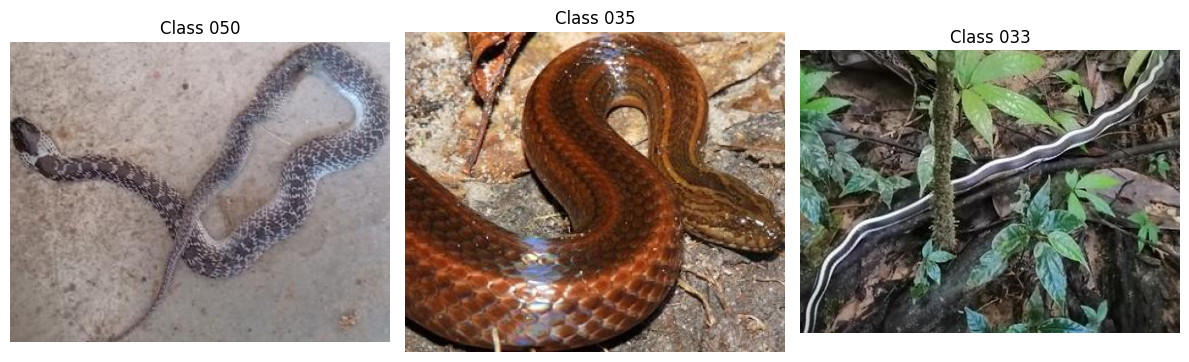

In [5]:
# Visualization
images = [path for class_dir in TRAIN_DIR.iterdir() if class_dir.is_dir() for path in class_dir.iterdir() if path.is_file()]
samples = random.sample(images, 3)

plt.figure(figsize=(12, 4))
for i, image_path in enumerate(samples, 1):
    image = Image.open(image_path).convert("RGB")
    plt.subplot(1, 3, i)
    plt.imshow(image)
    plt.title(f"Class {image_path.parent.name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Data Loading & Augmentation

In [ ]:
class PadToSquare:
    def __call__(self, image):
        w, h = image.size
        size = max(w, h)
        pad_w, pad_h = size - w, size - h
        padding = (pad_w // 2, pad_h // 2, pad_w - pad_w // 2, pad_h - pad_h // 2)
        return ImageOps.expand(image, padding, fill=(124, 116, 104))

train_tfms = transforms.Compose([
    PadToSquare(),
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    PadToSquare(),
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds = datasets.ImageFolder(VAL_DIR, transform=eval_tfms)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=1, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=1, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=1, pin_memory=True)

NUM_CLASSES = len(train_ds.classes)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)} | Classes: {NUM_CLASSES}")

Train: 18501 | Val: 2081 | Test: 1643 | Classes: 109


In [ ]:
# Load class Harmless & Venomous
classes_df = pd.read_csv(CLASSES_CSV).sort_values("label_idx").reset_index(drop=True)
venom_mask = torch.tensor(classes_df["MIVS"].values.astype(bool), device=DEVICE)

print(f"Venomous: {venom_mask.sum().item()} | Harmless: {(~venom_mask).sum().item()}")

## 4. Load Pretrained Model

In [ ]:
model = timm.create_model("convnextv2_base.fcmae_ft_in22k_in1k_384", pretrained=False, num_classes=0, drop_path_rate=0.2)
state_dict = torch.load(CKPT, map_location="cpu", weights_only=True)
model.load_state_dict(state_dict, strict=True)
model = model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())

print(
    f"Device: {DEVICE} | Classes: {NUM_CLASSES} | "
    f"Features: {model.num_features} | Params: {total_params / 1e6:.2f}M"
)

Device: cuda | Classes: 109 | Features: 1024 | Params: 87.69M


## 5. Training Configuration

### ArcFace & Safety Loss

In [ ]:
class ArcFace(nn.Module):
    def __init__(self, in_features, num_classes, scale=30.0, margin=0.3):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.weight = nn.Parameter(torch.empty(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, features, labels=None):
        cosine = F.linear(F.normalize(features), F.normalize(self.weight))
        cosine = cosine.clamp(-1 + 1e-7, 1 - 1e-7)

        if labels is None:
            return cosine * self.scale

        theta = torch.acos(cosine)
        target_cosine = torch.cos(theta + self.margin)
        one_hot = F.one_hot(labels, num_classes=cosine.size(1)).float()
        logits = cosine * (1 - one_hot) + target_cosine * one_hot

        return logits * self.scale

# Safety loss (minimize V -> H)
def safety_aware_loss(features, labels, arcface, criterion):
    margin_logits = arcface(features, labels)
    ce_loss = criterion(margin_logits, labels)

    raw_logits = arcface(features)
    probs = torch.softmax(raw_logits, dim=1)

    true_is_venom = venom_mask[labels]
    harmless_prob = probs[:, ~venom_mask].sum(dim=1)

    safety_loss = harmless_prob[true_is_venom].mean() if true_is_venom.any() else ce_loss.new_zeros(())
    loss = ce_loss + LAMBDA_SAFETY * safety_loss

    return loss, ce_loss, safety_loss

### Config hyperparams

In [ ]:
arcface = ArcFace(in_features=model.num_features, num_classes=NUM_CLASSES, scale=30.0, margin=0.3).to(DEVICE)
LAMBDA_SAFETY = 0.5

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
    {"params": model.parameters(), "lr": 2e-5}, # backbone
    {"params": arcface.parameters(), "lr": 1e-4}, # arcface weight
], weight_decay=2e-5)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - HOLD_EPOCHS, eta_min=1e-6)

## 6. Training

### Training function

In [ ]:
scaler = GradScaler("cuda")

def train_one_epoch(model, arcface, loader, criterion, optimizer):
    model.train()
    arcface.train()
    total_loss = total_ce = total_safety = correct = total = 0
    pbar = tqdm(loader, desc="Train", leave=False)

    for images, labels in pbar:
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast("cuda"):
            features = model(images)
            loss, ce_loss, safety_loss = safety_aware_loss(features, labels, arcface, criterion)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            preds = arcface(features.detach()).argmax(1)

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_ce += ce_loss.item() * bs
        total_safety += safety_loss.item() * bs
        correct += (preds == labels).sum().item()
        total += bs

        pbar.set_postfix(loss=f"{total_loss/total:.4f}", ce=f"{total_ce/total:.4f}", safety=f"{total_safety/total:.4f}", acc=f"{correct/total:.4f}")

    return total_loss / total, correct / total


def evaluate(model, arcface, loader, criterion):
    model.eval()
    arcface.eval()
    total_loss = correct = total = 0
    pbar = tqdm(loader, desc="Val", leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

            with autocast("cuda"):
                features = model(images)
                logits = arcface(features)
                loss = criterion(logits, labels)

            bs = images.size(0)
            total_loss += loss.item() * bs
            correct += (logits.argmax(1) == labels).sum().item()
            total += bs

            pbar.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")

    return total_loss / total, correct / total

### Training & save model

In [ ]:
best_val_acc = 0.0
patience = 4
early_stop = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, arcface, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, arcface, val_loader, criterion)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        early_stop = 0

        torch.save({
            "model": model.state_dict(),
            "arcface": arcface.state_dict(),
            "epoch": epoch + 1,
            "val_acc": best_val_acc,
            "lambda_safety": LAMBDA_SAFETY,
        }, BEST_MODEL)

    elif epoch + 1 > HOLD_EPOCHS:
        early_stop += 1

    if epoch + 1 >= HOLD_EPOCHS:
        scheduler.step()

    backbone_lr = optimizer.param_groups[0]["lr"]
    arcface_lr = optimizer.param_groups[1]["lr"]

    print(
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"LR: {backbone_lr:.2e}/{arcface_lr:.2e}"
    )

    if early_stop >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
print(f"Best model: {BEST_MODEL}")


Epoch 1/20


Train:   0%|          | 0/1028 [00:00<?, ?it/s]

Val:   0%|          | 0/116 [00:00<?, ?it/s]

Train Loss: 9.1894 | Train Acc: 0.5185 | Val Loss: 1.1993 | Val Acc: 0.6939 | LR: 2.00e-05/1.00e-04

Epoch 2/20


Train:   0%|          | 0/1028 [00:00<?, ?it/s]

...

Val:   0%|          | 0/116 [00:00<?, ?it/s]

Train Loss: 0.1819 | Train Acc: 0.9979 | Val Loss: 1.4294 | Val Acc: 0.8313 | LR: 4.14e-06/1.74e-05

Epoch 16/20


Train:   0%|          | 0/1028 [00:00<?, ?it/s]

Val:   0%|          | 0/116 [00:00<?, ?it/s]

Train Loss: 0.1594 | Train Acc: 0.9982 | Val Loss: 1.4697 | Val Acc: 0.8289 | LR: 2.81e-06/1.05e-05
Early stopping at epoch 16

Best Val Accuracy: 0.8313
Best model: /kaggle/working/convnextv2_base_arcface_safety_best.pt
